In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# set style for plots
sns.set_style('whitegrid')

In [23]:
# Load the dataset
dataset=pd.read_csv('diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
x=dataset.drop('Outcome',axis=1)
y=dataset['Outcome']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test) 

In [25]:
classifier= RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=42)
classifier.fit(x_train,y_train)

y_pred=classifier.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test,y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

[[77 22]
 [21 34]]

Accuracy Score: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



C:\Users\User\AppData\Local\Temp\ipykernel_16088\688448673.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')


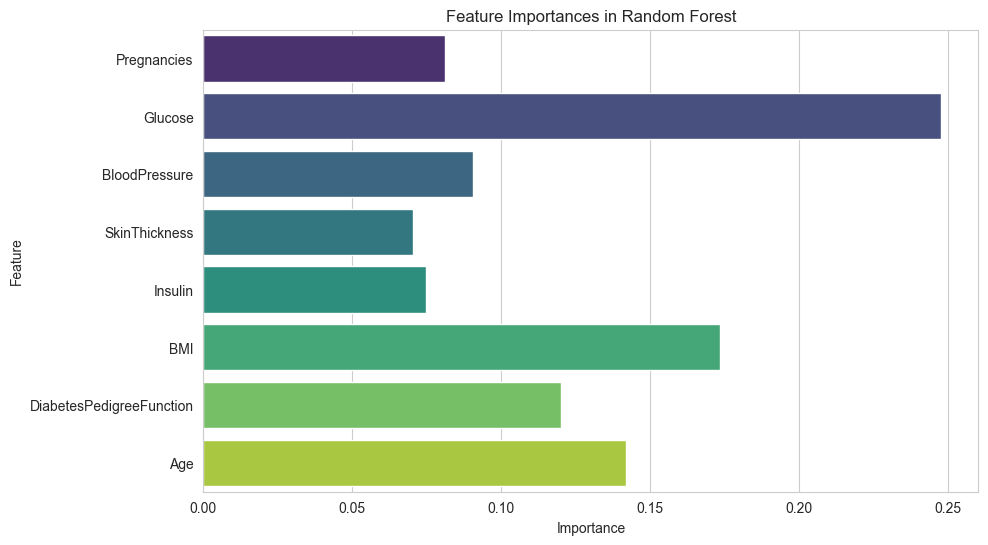

In [26]:
importances=classifier.feature_importances_
features_names=x.columns
feature_importance_df=pd.DataFrame({'Feature':features_names,'Importance':importances})
feature_importances_df=feature_importance_df.sort_values(by='Importance',ascending=False)
py.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')
py.title('Feature Importances in Random Forest')
py.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16088\2009036537.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


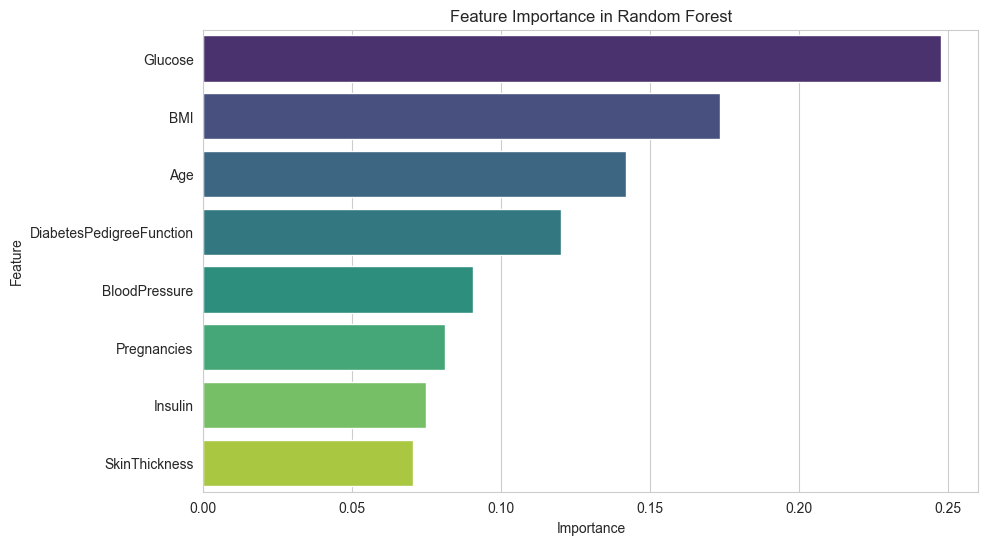

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = classifier.feature_importances_
feature_names = x.columns

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

plt.title('Feature Importance in Random Forest')
plt.show()

In [28]:
def predict_diabetes():
    try:
        print("----- Enter Patient Data -----")

        preg = int(input("Pregnancies (e.g., 2): "))
        glu = int(input("Glucose (e.g., 120): "))
        bp = int(input("Blood Pressure (e.g., 70): "))
        skin = int(input("Skin Thickness (e.g., 20): "))
        ins = int(input("Insulin (e.g., 80): "))
        bmi = float(input("BMI (e.g., 25.5): "))
        dpf = float(input("Diabetes Pedigree Function (e.g., 0.5): "))
        age = int(input("Age (e.g., 30): "))

        # Prepare data
        new_data = [[preg, glu, bp, skin, ins, bmi, dpf, age]]
        new_data_scaled = sc.transform(new_data)

        # Predict
        prediction = classifier.predict(new_data_scaled)
        probability = classifier.predict_proba(new_data_scaled)[0][1]

        print("\n"+"="*30)
        if prediction[0] == 1:
            print(f"Result: DIABETIC (Confidence: {probability * 100:.2f}%)")
        else:
            print(f"Result: NON-DIABETIC (Confidence: {(1 - probability) * 100:.2f}%)")
        print("="*30)

    except ValueError:
        print("Invalid input! Please enter numeric values.")


# Call the function
predict_diabetes()

----- Enter Patient Data -----

Result: NON-DIABETIC (Confidence: 96.00%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
